In [5]:
from CRNs import *
import numpy as np
import argparse
import time
import copy
import pickle


n_species = 6
n_complexes = 7
n_reactions = 4
force_reverse = True
L = np.array([[2, 1, 1, 0, 0, 0],
              [0, 0, 0, 1, 1, 1]])
n_cons = len(L)
n_lcs = n_complexes - n_species + n_cons
seed = 0
subset_group_ind = None

# n_species = 8
# n_complexes = 9
# n_reactions = 8
# force_reverse = True
# L = np.array([[2, 1, 1, 1, 0, 0, 0, 0],
#               [0, 0, 0, 0, 2, 1, 1, 1]])
# n_cons = len(L)
# n_lcs = n_complexes - n_species + n_cons
# complexes_per_class = [2, 3, 4]
# reactions_per_class = [1, 3, 6]
# subset_group_ind = None
# seed = 33339

E_range = 1
B_range = 1
F_range = 1
C0 = 1
beta = 1

n_graph_samples = 1

t_span = (0, 100000)
num_points = 10000
int_method = 'LSODA'
r_tol = 1e-10   
a_tol = 1e-10

if seed is not None:
    np.random.seed(seed)
    random.seed(seed)

# Initialize data logger and time profiler
data_logger = NetworkDataLogger()
profiler = TimeProfiler()
profiler.start_total_timer()


sampler = GridSampler(
    l0_range=(1e-3, 1e3),
    l0_grid_size=10,
    grid_dim=2,
    timeout_seconds=5,
    profiler=profiler,
    round_decimals=6,
    use_signal_alarms=False
)

for iter in range(n_graph_samples):
    seed = np.random.randint(1000000)

    # Time network generation
    profiler.start_timer("network_generation")
    try:
        r_n = ReactionNetwork(  
            n_species, 
            n_complexes, n_reactions, n_lcs, 
            L, seed, force_reverse=force_reverse, subset_group_ind=subset_group_ind, 
            #complexes_per_class=complexes_per_class, reactions_per_class=reactions_per_class
        )
        reac_rates = generate_thermodynamic_rates(r_n, C0, beta, E_range, B_range, F_range)
        r_n.update_rates(reac_rates)
        profiler.end_timer("network_generation")
    except Exception as e:
        profiler.end_timer("network_generation")
        print(f"Error creating reaction network: {e}, skipping...")
        continue

    # Time conservation group analysis
    profiler.start_timer("conservation_analysis")
    M_0t1, M_1t0, M_0b1 = count_conservation_group_changes(r_n)
    profiler.end_timer("conservation_analysis")
    
    # Time data storage operations
    profiler.start_timer("data_storage")
    cycles = compute_cycles(r_n)
    profiler.end_timer("data_storage")

    # Time simulator initialization
    profiler.start_timer("simulator_init")
    sim = ReactionNetworkSimulator(r_n)
    profiler.end_timer("simulator_init")
    
    
    # Time conservation laws solving
    profiler.start_timer("conservation_laws")
    sim.solve_conservation_laws()
    profiler.end_timer("conservation_laws")
    
    # Time symbolic RHS generation
    profiler.start_timer("symbolic_rhs")
    reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
    profiler.end_timer("symbolic_rhs")
    
    # Time derivatives computation
    profiler.start_timer("derivatives")
    # Only compute the derivatives we actually use
    dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
    # Store the derivative functions that will be reused in adaptive sampling
    precomputed_derivatives = (dR_dC_func, dR_dl_func)

    profiler.end_timer("derivatives")
    
    # Time rates creation
    profiler.start_timer("rates_creation")
    rates = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])
    profiler.end_timer("rates_creation")
    
    # Time flexible RHS creation
    profiler.start_timer("flexible_rhs")
    flexible_reduced_ode_rhs = sim.make_reduced_rhs_with_conservation_flexible()
    profiler.end_timer("flexible_rhs")
 
    # Use adaptive sampling instead of fixed sampling
    # Note: The adaptive sampler handles its own internal timing with "adaptive_" prefixed timers
    profiler.start_timer("adaptive_sampling")
    sign_conditions, C_full_list, dC_dl_list, l0_list, sample_count, convergence_reached = sampler.sample_sign_conditions(
        sim=sim,
        L=L,
        t_span=t_span,
        num_points=num_points,
        int_method=int_method,
        r_tol=r_tol,
        a_tol=a_tol,
        precomputed_derivatives=precomputed_derivatives
    )
    profiler.end_timer("adaptive_sampling")
    
    # Reset sampler for next network
    sampler.reset()
    
    # Log the network data using the new logger
    profiler.start_timer("data_logging")
    data_logger.log_network(
        r_n=r_n,
        M_0t1=M_0t1,
        M_1t0=M_1t0,
        M_0b1=M_0b1,
        cycles=cycles,
        sign_conditions=sign_conditions,
        C_full_list=C_full_list,
        dC_dl_list=dC_dl_list,
        l0_list=l0_list,
        iteration=iter,
        seed=seed,
        E_range=E_range,
        B_range=B_range,
        F_range=F_range,
        C0=C0,
        beta=beta,
        sample_count=sample_count,  # Add sampling statistics
        convergence_reached=convergence_reached
    )
    profiler.end_timer("data_logging")

    if iter%5 == 0:
        print(f"Iteration {iter} complete")

profiler.end_total_timer()

# Print detailed timing information
profiler.print_summary()


Iteration 0 complete

=== TIMING SUMMARY ===
Total time: 2.25 seconds

Adaptive Sampling Breakdown:
  adaptive_integration: 1.79 seconds (79.5%)
  adaptive_nnls: 0.27 seconds (11.8%)
  adaptive_sensitivity_analysis: 0.04 seconds (1.8%)
  adaptive_species_recovery: 0.00 seconds (0.1%)
  adaptive_sign_processing: 0.00 seconds (0.1%)
  adaptive_initial_conditions: 0.00 seconds (0.1%)
derivatives: 0.08 seconds (3.4%)
network_generation: 0.02 seconds (0.9%)
flexible_rhs: 0.02 seconds (0.9%)
symbolic_rhs: 0.02 seconds (0.7%)
conservation_laws: 0.01 seconds (0.6%)
adaptive_sampling: 0.00 seconds (0.1%)
data_storage: 0.00 seconds (0.0%)
data_logging: 0.00 seconds (0.0%)
rates_creation: 0.00 seconds (0.0%)
conservation_analysis: 0.00 seconds (0.0%)
simulator_init: 0.00 seconds (0.0%)

Other operations: 0.00 seconds (0.1%)



In [2]:
r_n.get_reaction_strings_simple(include_reverse=False)
print(r_n.get_rates())


[0.6313065348955412, 1.0155882251192572, 0.15136783917370458, 0.25666535237153154, 3.0101312243870844, 0.87813531961049, 1.0099941376500257, 1.0882141409081165, 0.36169463695383475, 0.26072404715538133, 0.6039123379481043, 0.4161612044063426, 0.5755556150358879, 0.1395479051911465, 3.4325368867711576, 0.3833628031330608]


In [3]:
r_n_n = data_logger.reconstruct_network(0)
sim = ReactionNetworkSimulator(r_n_n)
r_n_n.get_reaction_strings_simple(include_reverse=True)
print(r_n_n.get_rates())

[0.6313065348955412, 1.0155882251192572, 0.15136783917370458, 0.25666535237153154, 3.0101312243870844, 0.87813531961049, 1.0099941376500257, 1.0882141409081165, 0.36169463695383475, 0.26072404715538133, 0.6039123379481043, 0.4161612044063426, 0.5755556150358879, 0.1395479051911465, 3.4325368867711576, 0.3833628031330608]


In [55]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import numpy as np


network_index = 0

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])

print(M_values[network_index])
print(sign_conditions[network_index])
print(data_logger.get_network_by_index(network_index)['cycles'])
sign_conditions_ids = get_sign_condition_ids(sign_conditions[network_index])
print(len(set(sign_conditions_ids)))
print(sign_conditions_ids)

C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']
l0_list = data_logger.get_network_by_index(network_index)['l0_list']


# Extract coordinates and values and transform to log space
l0_x = [np.log10(l0[0]) for l0 in l0_list]
l0_y = [np.log10(l0[1]) for l0 in l0_list]
C_vals_list = [[np.log10(C_full[ind]) for C_full in C_full_list] for ind in range(len(C_full_list[0]))]

# Create grid of points in log space
grid_x, grid_y = np.meshgrid(
    np.linspace(min(l0_x), max(l0_x), 10),
    np.linspace(min(l0_y), max(l0_y), 10)
)

# Interpolate values in log space
points = np.column_stack((l0_x, l0_y))
#C_interpolated_list = [griddata(points, np.log10(C_vals_list[ind]), (grid_x, grid_y), method='linear') for ind in range(len(C_vals_list))]
C_interpolated_list = [griddata(points, C_vals_list[ind], (grid_x, grid_y), method='linear') for ind in range(len(C_vals_list))]

dR_dC_func, dR_dl_func = precomputed_derivatives
rates = np.array([data_logger.get_network_by_index(network_index)['network_params']['reactions'][r_idx][2] for r_idx in range(len(data_logger.get_network_by_index(network_index)['network_params']['reactions']))])

def clamp_sign(sign_array, off):
    result = np.zeros_like(sign_array)
    result[sign_array > off] = 1
    result[sign_array < -off] = -1
    return result

sign_conditions_fine = []
l0_list_fine = []
dC_dl_list_fine = []
C_full_list_fine = []
d_log_C_d_log_l0_list_fine = []

for i in range(grid_x.shape[0]):
    for j in range(grid_x.shape[1]):
        l0 = [10**grid_x[i, j], 10**grid_y[i, j]]
        C_full = np.array([10**C_interpolated_list[ind][i, j] for ind in range(len(C_interpolated_list))])
        _, C_reduced = sim.get_const_and_reduced_init(C_full)
        dC_dl = sim.dC_dl_func(C_reduced, l0, rates, dR_dC_func, dR_dl_func)
        dC_dl_full = sim.compute_dC_dk_full(dC_dl)
        dC_dl_list_fine.append(dC_dl_full)
        C_full_list_fine.append(C_full)


        d_log_C_d_log_l0 = np.zeros_like(dC_dl_full)
        for k in range(dC_dl_full.shape[0]):
            for l in range(dC_dl_full.shape[1]):
                d_log_C_d_log_l0[k, l] = dC_dl_full[k, l] * l0[l] / C_full[k]

        d_log_C_d_log_l0_list_fine.append(d_log_C_d_log_l0)
        sign_conditions_fine.append(clamp_sign(d_log_C_d_log_l0, 1e-20).tolist())
        l0_list_fine.append(l0)


# for (i, l0) in enumerate(l0_list):
#         C_full = C_full_list[i]
#         _, C_reduced = sim.get_const_and_reduced_init(C_full)
#         dC_dl = sim.dC_dl_func(C_reduced, l0, rates, dR_dC_func, dR_dl_func)
#         dC_dl_full = sim.compute_dC_dk_full(dC_dl)
#         dC_dl_list.append(dC_dl_full)
#         sign_conditions_fine.append(np.sign(np.round(dC_dl_full, decimals=6)).tolist())
#         l0_list_fine.append(l0)


4
[[-1.0, -1.0], [1.0, 1.0], [1.0, -1.0], [1.0, 1.0], [0.0, -1.0], [0.0, 1.0], [0.0, 1.0], [0.0, 1.0]]
(Matrix([
[ 0,  0],
[ 0,  0],
[ 0,  0],
[ 1,  0],
[-1,  1],
[ 0, -1],
[ 1,  0],
[ 0,  1]]), [['r6: F+G -> G+G', 'r9: E -> F+G', 'r12: G+G -> E'], ['r8: F+G -> E', 'r11: F+H -> F+G', 'r14: E -> F+H']])
5
[0, 1, 2, 1, 3, 4, 4, 4]


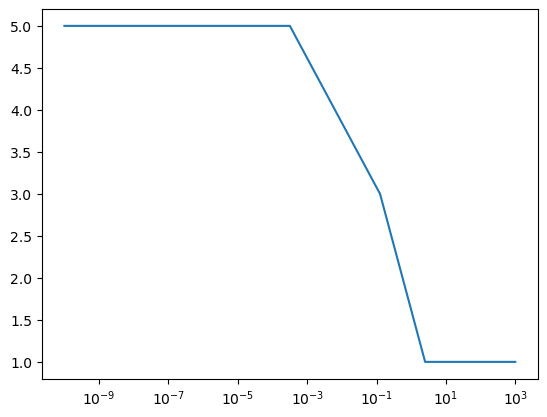

In [56]:
cut_list = np.logspace(-10, 3, 11)
n_conds_list = []
for cut in cut_list:
    # clamped_sign_conditions_fine = get_sign_condition_ids([clamp_sign(p, cut).tolist() for p in d_log_C_d_log_l0_list_fine])
    tensor_list = [clamp_sign(p, cut) for p in d_log_C_d_log_l0_list_fine]
    n_conds, sign_count_ids = count_unique_tensors_with_ids(tensor_list)
    n_conds_list.append(n_conds)


plt.plot(cut_list, n_conds_list)
plt.xscale('log')
plt.show()

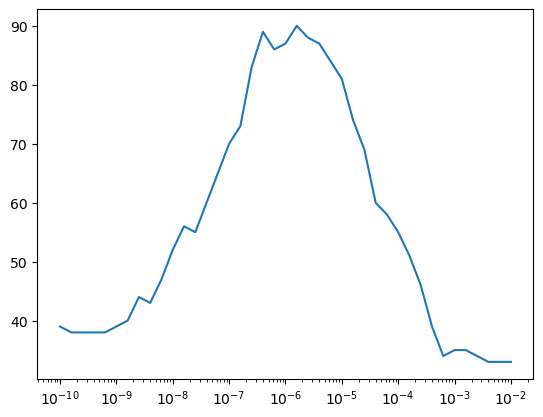

In [26]:
cut_list = np.logspace(-10, -2, 41)
n_conds_list = []
for cut in cut_list:
    clamped_sign_conditions_fine = get_sign_condition_ids([clamp_sign(p, cut).tolist() for p in d_log_C_d_log_l0_list_fine])
    #clamped_sign_conditions_fine = get_sign_condition_ids([clamp_sign(p, cut).tolist() for p in d_log_C_d_log_l0_list_fine])
    n_conds_list.append(len(set(clamped_sign_conditions_fine)))

plt.plot(cut_list, n_conds_list)
plt.xscale('log')
plt.show()



[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

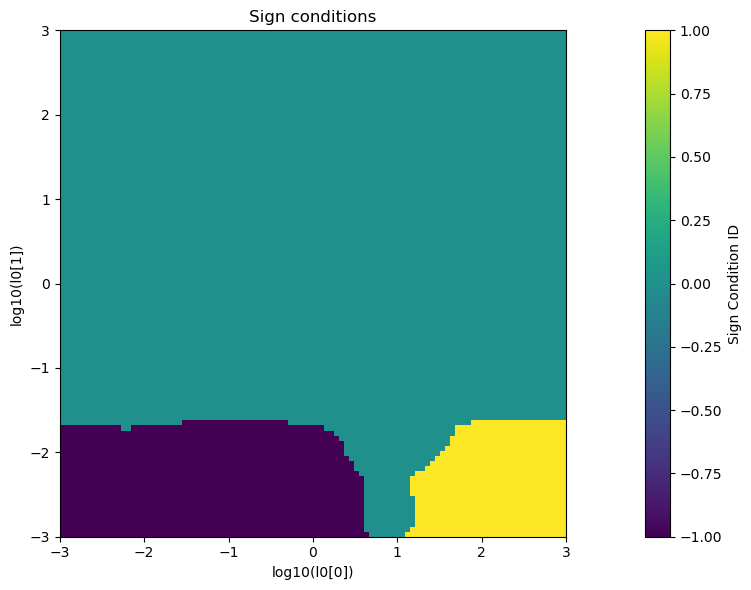

In [53]:
C_ind = 2
l_ind = 1

l0_x = np.array([l0[0] for l0 in l0_list_fine])  
l0_y = np.array([l0[1] for l0 in l0_list_fine])  
dC_dl_data = [d_log_C_d_log_l0_list_fine[i][C_ind,l_ind]  for i in range(len(d_log_C_d_log_l0_list_fine))]
C_data = [np.log10(C_full_list_fine[i][C_ind])  for i in range(len(C_full_list_fine))]
#C_data = [C_full_list_fine[i][C_ind]  for i in range(len(C_full_list_fine))]

cut = 1e-3

sign_condition_ids = get_sign_condition_ids([clamp_sign(p, cut).tolist() for p in d_log_C_d_log_l0_list_fine])
n_conds, sign_condition_ids = count_unique_tensors_with_ids([clamp_sign(p, cut).tolist() for p in d_log_C_d_log_l0_list_fine])

print(sign_condition_ids)
print(len(set(sign_condition_ids)))

# Create figure with two subplots side by side
fig, (ax) = plt.subplots(1, 1, figsize=(16,6))

p_vals = C_data
p_vals = dC_dl_data
p_vals = [clamp_sign(p, 1e-1) for p in p_vals]
cmap = 'viridis'

# p_vals = sign_condition_ids
# cmap = 'tab10'

# Reshape sign_condition_ids into a 2D array
n = int(np.sqrt(len(p_vals)))  # Assuming square grid
p_values = np.array(p_vals).reshape(n, n)

# Plot using imshow
im = ax.imshow(p_values, origin='lower', aspect='auto',
                extent=[np.log10(l0_x.min()), np.log10(l0_x.max()),
                        np.log10(l0_y.min()), np.log10(l0_y.max())],
                cmap=cmap)
ax.set_xlabel('log10(l0[0])')
ax.set_ylabel('log10(l0[1])')
ax.set_title('Sign conditions')
ax.set_aspect(1)

fig.colorbar(im, ax=ax, label='Sign Condition ID')

plt.tight_layout()
plt.show()


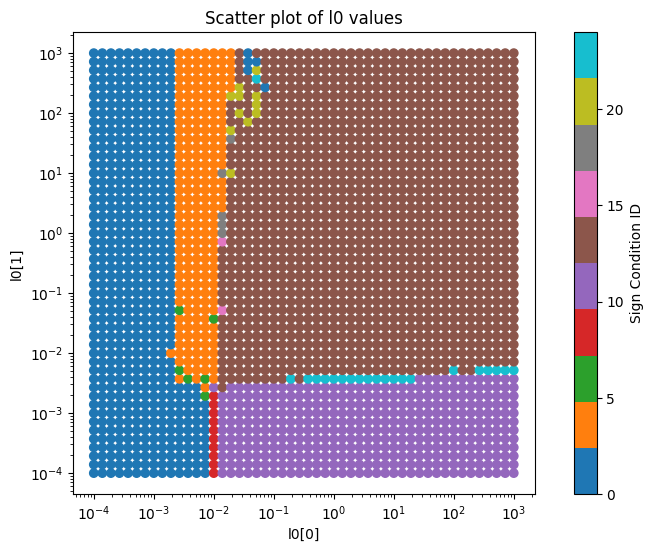

In [112]:

l0_list = data_logger.get_network_by_index(network_index)['l0_list']
l0_x = [l0[0] for l0 in l0_list]
l0_y = [l0[1] for l0 in l0_list]

C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']
C_vals = [C_full[0] for C_full in C_full_list]

sign_conditions = data_logger.get_network_by_index(network_index)['sign_conditions']
sign_condition_ids = get_sign_condition_ids(sign_conditions)


# Plot the l0 values
plt.figure(figsize=(10,6))
scatter = plt.scatter(l0_x, l0_y, c=sign_condition_ids, cmap='tab10')
plt.xlabel('l0[0]')
plt.ylabel('l0[1]') 
plt.xscale('log')
plt.yscale('log')

plt.title('Scatter plot of l0 values')
plt.gca().set_aspect('equal')
plt.colorbar(scatter, label='Sign Condition ID')
#plt.grid(True)
plt.show()

[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.

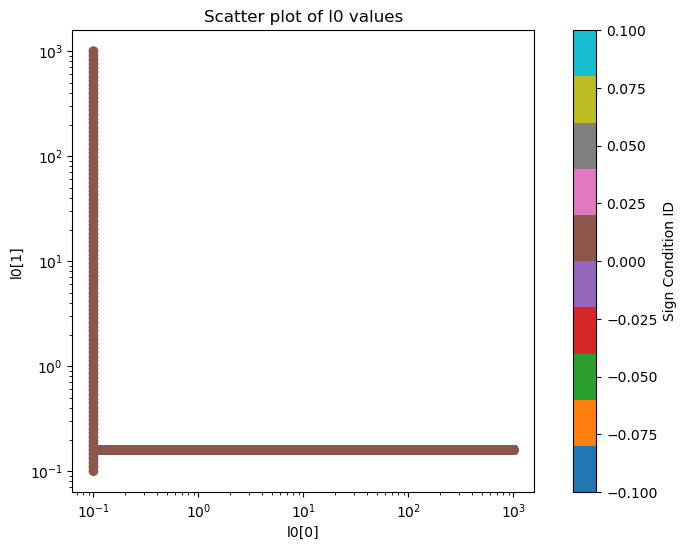

In [9]:
import matplotlib.pyplot as plt

C_ind = 1
l_ind = 1

l0_x = np.array([l0[0] for l0 in l0_list_fine])  
l0_y = np.array([l0[1] for l0 in l0_list_fine])  
dC_dl_data = [dC_dl_list_fine[i][C_ind,l_ind]  for i in range(len(dC_dl_list_fine))]


sign_condition_ids = get_sign_condition_ids(sign_conditions_fine)


#dC_dl_data = np.sign(np.round([dC_dl[5,0] for dC_dl in dC_dl_list], decimals=16))
#dC_dl_data = [dC_dl[5,1] for dC_dl in dC_dl_list_fine]
#dC_dl_data = [clamp_sign(dC_dl[5,0], 1e-12) for dC_dl in dC_dl_list_fine] # try savitsky golay filter


#dC_dl_data = [dC_dl_list_fine[i][C_ind,l_ind]  for i in range(len(dC_dl_list_fine))] # try savitsky golay filter
#dC_dl_data = [dC_dl_list_fine[i][C_ind,l_ind] / (C_full_list_fine[i][C_ind]) for i in range(len(dC_dl_list_fine))] # try savitsky golay filter
#dC_dl_data = [clamp_sign(dC_dl_data[i], 1e-3) for i in range(len(dC_dl_data))]
#dC_dl_data = [np.sign(dC_dl_data[i] + 1e-3) for i in range(len(dC_dl_data))]

#dC_dl_data = [np.log10(np.abs(dC_dl_data[i])) for i in range(len(dC_dl_data))]

print(dC_dl_data)

print(sign_condition_ids)
# Plot the l0 values
plt.figure(figsize=(10,6))
scatter = plt.scatter(l0_x, l0_y, c=dC_dl_data, cmap='tab10')
#scatter = plt.scatter(l0_x, l0_y, c=sign_condition_ids, cmap='tab10')
plt.xlabel('l0[0]')
plt.ylabel('l0[1]')     
plt.xscale('log')
plt.yscale('log')

plt.title('Scatter plot of l0 values')
plt.gca().set_aspect('equal')
plt.colorbar(scatter, label='Sign Condition ID')
#plt.grid(True)
plt.show()



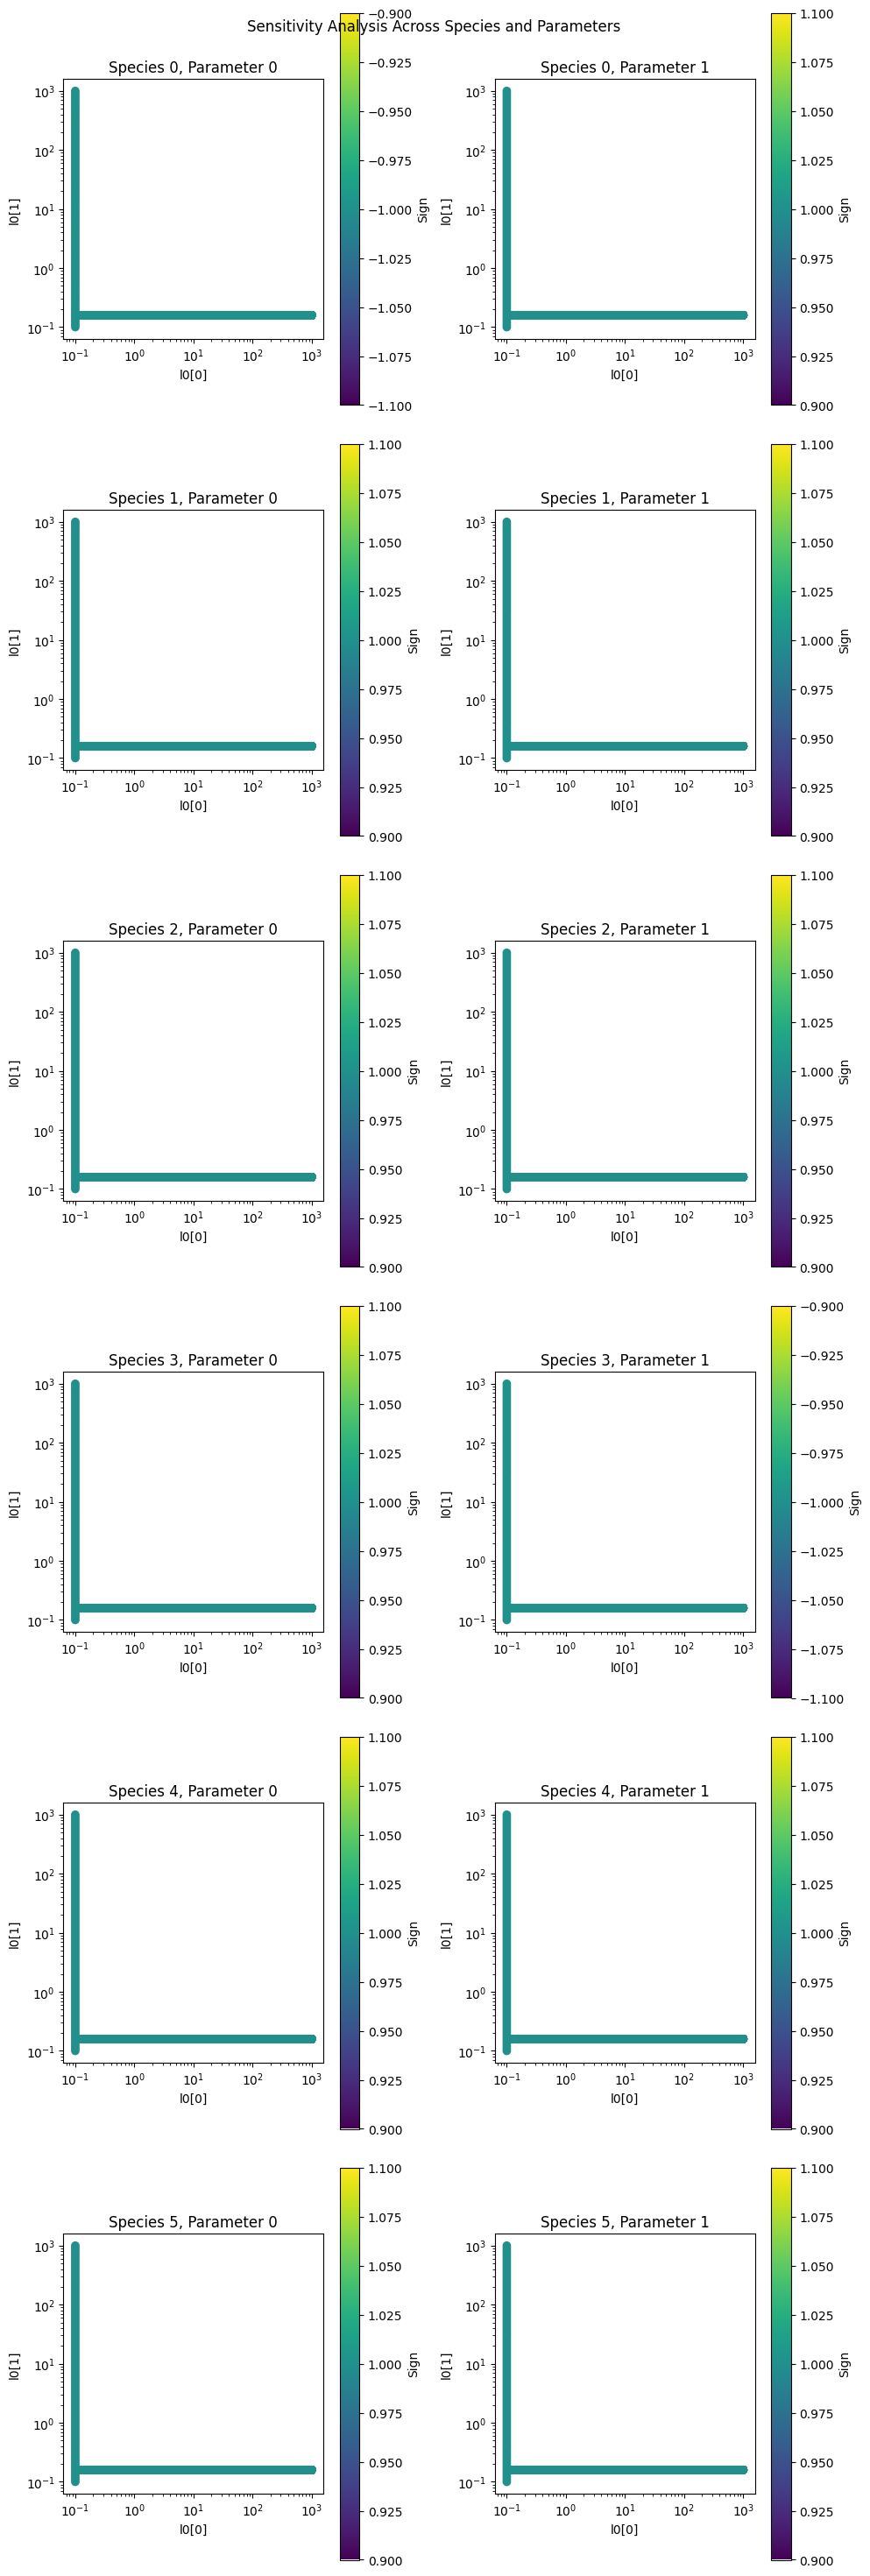

In [ ]:
# Create array of subplots for each C_ind and l_ind combination
n_species = dC_dl_list_fine[0].shape[0]  # Number of species
n_params = dC_dl_list_fine[0].shape[1]   # Number of parameters

fig, axes = plt.subplots(n_species, n_params, figsize=(5*n_params, 5*n_species))
fig.suptitle('Sensitivity Analysis Across Species and Parameters')

for C_ind in range(n_species):
    for l_ind in range(n_params):
        # Get sensitivity data for this species/parameter combination
        dC_dl_data = [dC_dl_list_fine[i][C_ind,l_ind] for i in range(len(dC_dl_list_fine))]
        dC_dl_data = [np.sign(d + 1e-8) for d in dC_dl_data]
        
        # Create scatter plot in appropriate subplot
        scatter = axes[C_ind,l_ind].scatter(l0_x, l0_y, c=dC_dl_data)
        axes[C_ind,l_ind].set_xscale('log')
        axes[C_ind,l_ind].set_yscale('log')
        axes[C_ind,l_ind].set_aspect('equal')
        
        # Add labels
        axes[C_ind,l_ind].set_xlabel('l0[0]')
        axes[C_ind,l_ind].set_ylabel('l0[1]')
        axes[C_ind,l_ind].set_title(f'Species {C_ind}, Parameter {l_ind}')
        
        # Add colorbar
        plt.colorbar(scatter, ax=axes[C_ind,l_ind], label='Sign')

plt.tight_layout()
plt.show()

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 2, 3, 1, 1, 1, 1, 1, 1, 4, 4, 4, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 4, 4, 4, 3, 3, 3, 1, 1, 1, 1]


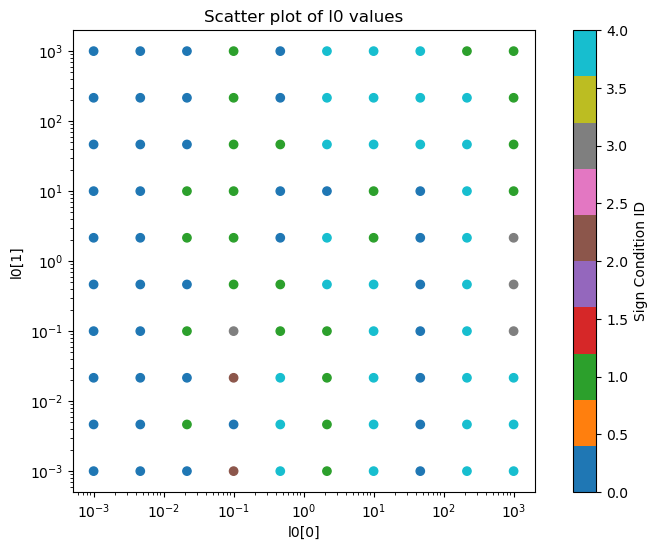

In [54]:
import matplotlib.pyplot as plt

network_index = 0

print
l0_list = data_logger.get_network_by_index(network_index)['l0_list']
l0_x = [l0[0] for l0 in l0_list]
l0_y = [l0[1] for l0 in l0_list]

sign_conditions = data_logger.get_network_by_index(network_index)['sign_conditions']
sign_condition_ids = get_sign_condition_ids(sign_conditions)


print(sign_condition_ids)
# Plot the l0 values
plt.figure(figsize=(10,6))
scatter = plt.scatter(l0_x, l0_y, c=sign_condition_ids, cmap='tab10')
plt.xlabel('l0[0]')
plt.ylabel('l0[1]') 
plt.xscale('log')
plt.yscale('log')

plt.title('Scatter plot of l0 values')
plt.gca().set_aspect('equal')
plt.colorbar(scatter, label='Sign Condition ID')
#plt.grid(True)
plt.show()

[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 2, 0, 1, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 3, 0, 0, 1, 2, 0, 0, 1, 4, 0, 1, 0, 5, 0, 0, 0, 1, 0, 0, 3, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 6, 0, 0, 1, 1, 0, 0, 1, 7, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 2, 2, 0, 0, 6, 0, 0, 1, 0, 1, 0, 0, 0, 0, 2, 1, 0, 1, 0, 0, 0, 0, 6, 1, 2, 0, 0, 6, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 6, 0, 1, 0, 0, 0, 1, 3, 0, 1, 0, 0, 1, 2, 0, 1, 0, 3, 0, 0, 2, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 6, 0, 1, 1, 0, 0, 0, 0, 1, 7, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 3, 1, 0, 0, 0, 0, 0, 0, 3, 0, 1, 0, 0, 0, 0, 1, 0, 0, 3, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 2, 1, 0, 2, 0, 0, 0, 1, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 6, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 2, 1, 0]


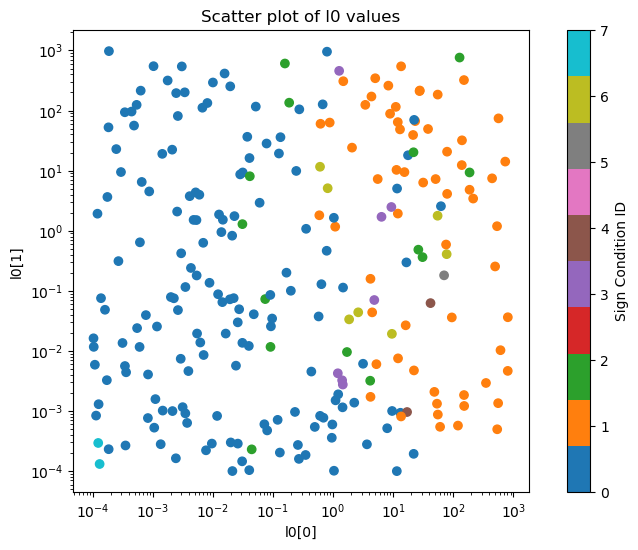

In [ ]:
import matplotlib.pyplot as plt

network_index = 0

print
l0_list = data_logger.get_network_by_index(network_index)['l0_list']
l0_x = [l0[0] for l0 in l0_list]
l0_y = [l0[1] for l0 in l0_list]

sign_conditions = data_logger.get_network_by_index(network_index)['sign_conditions']
sign_condition_ids = get_sign_condition_ids(sign_conditions)


print(sign_condition_ids)
# Plot the l0 values
plt.figure(figsize=(10,6))
scatter = plt.scatter(l0_x, l0_y, c=sign_condition_ids, cmap='tab10')
plt.xlabel('l0[0]')
plt.ylabel('l0[1]') 
plt.xscale('log')
plt.yscale('log')

plt.title('Scatter plot of l0 values')
plt.gca().set_aspect('equal')
plt.colorbar(scatter, label='Sign Condition ID')
#plt.grid(True)
plt.show()

In [ ]:
M_values

array([2, 0, 6, 0, 0, 0, 4, 4, 4, 4, 2, 4, 6, 4, 0, 2, 0, 0, 2, 0, 2, 0,
       4, 0, 2, 0, 6, 2, 4, 0, 2, 2, 0, 6, 4, 6, 2, 2, 2, 2, 4, 2, 2, 0,
       4, 0, 2, 2, 6, 2])

2


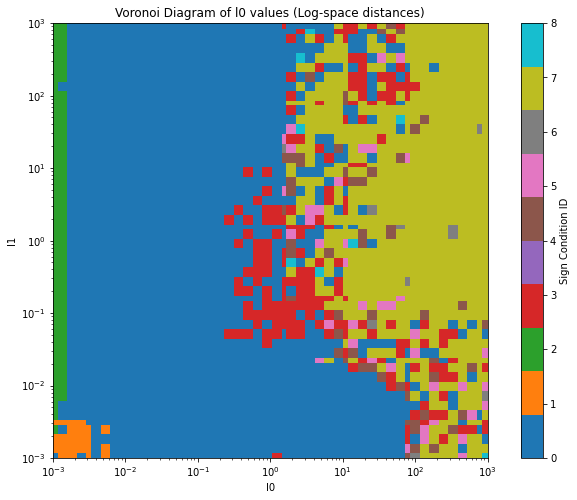

In [41]:
import numpy as np
import matplotlib.pyplot as plt

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])

grid_size = 200

network_index = 0
print(M_values[network_index])

l0_list = data_logger.get_network_by_index(network_index)['l0_list']
l0_x = [l0[0] for l0 in l0_list]
l0_y = [l0[1] for l0 in l0_list]

sign_conditions = data_logger.get_network_by_index(network_index)['sign_conditions']
sign_condition_ids = get_sign_condition_ids(sign_conditions)

# Create a much finer grid using log spacing
x_min, x_max = min(l0_x), max(l0_x)
y_min, y_max = min(l0_y), max(l0_y)

# Add padding
padding_x = (x_max - x_min) * 0.2
padding_y = (y_max - y_min) * 0.2

# Create grid bounds in log space
x_start = max(x_min - padding_x, 1e-10)
x_end = x_max + padding_x
y_start = max(y_min - padding_y, 1e-10)
y_end = y_max + padding_y

# Create a very fine grid using log spacing
x_grid = np.logspace(np.log10(x_start), np.log10(x_end), grid_size)
y_grid = np.logspace(np.log10(y_start), np.log10(y_end), grid_size)

# Filter out any non-finite values
x_grid = x_grid[np.isfinite(x_grid)]
y_grid = y_grid[np.isfinite(y_grid)]

X, Y = np.meshgrid(x_grid, y_grid)

# Calculate regions for each grid point using log-space distances
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Find the closest original point using log-space distances
        log_distances = np.sqrt((np.log10(l0_x) - np.log10(X[i, j]))**2 + 
                               (np.log10(l0_y) - np.log10(Y[i, j]))**2)
        closest_idx = np.argmin(log_distances)
        Z[i, j] = sign_condition_ids[closest_idx]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the colored regions
mesh = ax.pcolormesh(X, Y, Z, cmap='tab10', shading='auto')

# # Plot the original points
# scatter = ax.scatter(l0_x, l0_y, c=sign_condition_ids, cmap='tab10', s=100, 
#                     edgecolors='black', linewidth=0, zorder=5)

# Set log scales
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(min(l0_x), max(l0_x))
ax.set_ylim(min(l0_y), max(l0_y))

ax.set_xlabel('l0')
ax.set_ylabel('l1')
ax.set_title('Voronoi Diagram of l0 values (Log-space distances)')
ax.set_aspect('equal')

# Add colorbar
plt.colorbar(mesh, ax=ax, label='Sign Condition ID')

plt.show()

4


/var/folders/vz/mzz963fn35g6stbyn1w_x0jc0000gn/T/ipykernel_43134/4003078849.py:77: RuntimeWarning: overflow encountered in power
  v1_linear = 10**v1


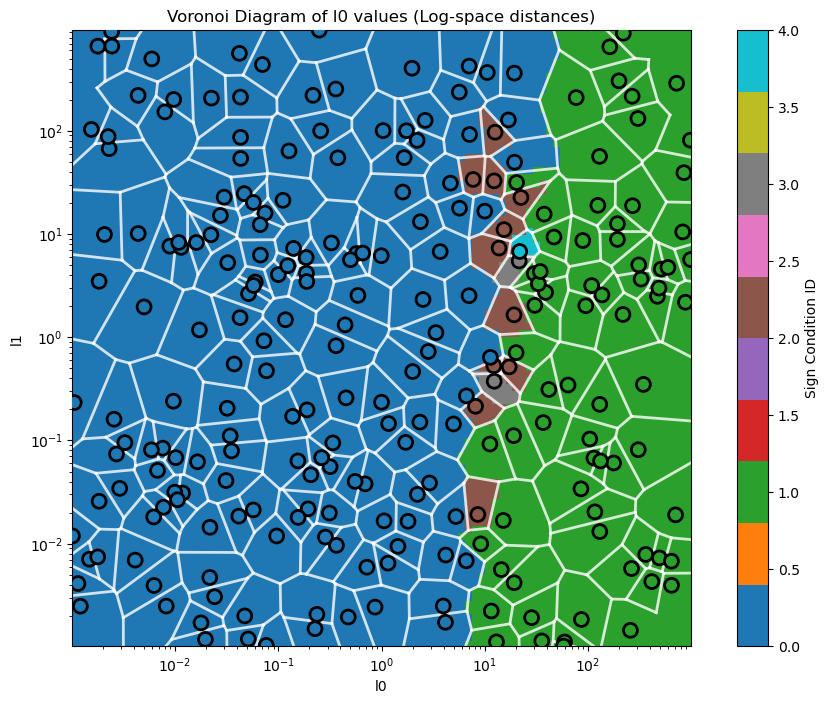

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

network_index = 7

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])

grid_size = 200

print(M_values[network_index])

l0_list = data_logger.get_network_by_index(network_index)['l0_list']
l0_x = [l0[0] for l0 in l0_list]
l0_y = [l0[1] for l0 in l0_list]

sign_conditions = data_logger.get_network_by_index(network_index)['sign_conditions']
sign_condition_ids = get_sign_condition_ids(sign_conditions)

# Create points array
points = np.column_stack((l0_x, l0_y))

# Transform points to log space for Voronoi computation
log_points = np.column_stack((np.log10(l0_x), np.log10(l0_y)))
vor = Voronoi(log_points)

# Create a much finer grid using log spacing
x_min, x_max = min(l0_x), max(l0_x)
y_min, y_max = min(l0_y), max(l0_y)

# Add padding
padding_x = (x_max - x_min) * 0.2
padding_y = (y_max - y_min) * 0.2

# Create grid bounds in log space
x_start = max(x_min - padding_x, 1e-10)
x_end = x_max + padding_x
y_start = max(y_min - padding_y, 1e-10)
y_end = y_max + padding_y

# Create a very fine grid using log spacing
x_grid = np.logspace(np.log10(x_start), np.log10(x_end), grid_size)
y_grid = np.logspace(np.log10(y_start), np.log10(y_end), grid_size)

# Filter out any non-finite values
x_grid = x_grid[np.isfinite(x_grid)]
y_grid = y_grid[np.isfinite(y_grid)]

X, Y = np.meshgrid(x_grid, y_grid)

# Calculate regions for each grid point using log-space distances
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Find the closest original point using log-space distances
        log_distances = np.sqrt((np.log10(l0_x) - np.log10(X[i, j]))**2 + 
                               (np.log10(l0_y) - np.log10(Y[i, j]))**2)
        closest_idx = np.argmin(log_distances)
        Z[i, j] = sign_condition_ids[closest_idx]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the colored regions
mesh = ax.pcolormesh(X, Y, Z, cmap='tab10', shading='auto')

# Plot the original points
scatter = ax.scatter(l0_x, l0_y, c=sign_condition_ids, cmap='tab10', s=100, 
                    edgecolors='black', linewidth=2, zorder=5)

# Add Voronoi region outlines (transformed from log space)
for ridge in vor.ridge_vertices:
    if ridge[0] != -1 and ridge[1] != -1:  # Skip ridges extending to infinity
        v1 = vor.vertices[ridge[0]]
        v2 = vor.vertices[ridge[1]]
        # Transform back from log space to linear space
        v1_linear = 10**v1
        v2_linear = 10**v2
        ax.plot([v1_linear[0], v2_linear[0]], [v1_linear[1], v2_linear[1]], 
                'white', linewidth=2, alpha=0.8)

# Set log scales
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(min(l0_x), max(l0_x))
ax.set_ylim(min(l0_y), max(l0_y))

ax.set_xlabel('l0')
ax.set_ylabel('l1')
ax.set_title('Voronoi Diagram of l0 values (Log-space distances)')
ax.set_aspect('equal')

# Add colorbar
plt.colorbar(mesh, ax=ax, label='Sign Condition ID')

plt.show()

In [ ]:
import numpy as np
from scipy.spatial import Voronoi
from collections import defaultdict
import networkx as nx

def count_connected_components_voronoi(points, labels, log_transform=True):
    """
    Count connected components in Voronoi diagram using graph approach.
    
    Args:
        points: array of shape (n, 2) with xy coordinates
        labels: array of length n with labels for each point
    
    Returns:
        dict: {label: number_of_connected_components}
    """
    # Create Voronoi diagram

    # Transform points to log space for Voronoi computation
    if log_transform:
        points = np.column_stack((np.log10(points[:,0]), np.log10(points[:,1])))
    vor = Voronoi(points)

    
    # Build adjacency graph
    G = nx.Graph()
    
    # Add nodes for each point
    for i, label in enumerate(labels):
        G.add_node(i, label=label)
    
    # Add edges between adjacent Voronoi regions
    for ridge in vor.ridge_points:
        if ridge[0] != -1 and ridge[1] != -1:  # Skip ridges to infinity
            point1, point2 = ridge[0], ridge[1]
            # Only connect points with the same label
            if labels[point1] == labels[point2]:
                G.add_edge(point1, point2)
    
    # Find connected components for each label
    label_components = defaultdict(int)
    
    # Group nodes by label
    nodes_by_label = defaultdict(list)
    for node in G.nodes():
        label = G.nodes[node]['label']
        nodes_by_label[label].append(node)
    
    # Count connected components for each label
    for label, nodes in nodes_by_label.items():
        # Get subgraph for this label
        subgraph = G.subgraph(nodes)
        # Count connected components in subgraph
        num_components = nx.number_connected_components(subgraph)
        label_components[label] = num_components
    
    return dict(label_components)

# Usage example:
points = np.column_stack((l0_x, l0_y))
labels = sign_condition_ids
component_counts = count_connected_components_voronoi(points, labels)
print(component_counts)

{0: 1, 1: 1, 2: 5, 3: 2, 4: 1}


In [ ]:
print(len(data_logger.get_network_by_index(6)['l0_list']))
print(len(data_logger.get_network_by_index(6)['sign_conditions']))

29
29


In [ ]:
sample_counts = [network['additional_data']['sample_count'] for network in data_logger.network_data]
print(sample_counts)

l0_list = [network['l0_list'] for network in data_logger.network_data]
print("Number of l0 values used for each network:")
print(l0_list)

[46, 38, 21, 21, 23, 53, 27, 39, 23, 30, 57, 30, 21, 32, 26, 41, 96, 160, 86, 110, 51, 24, 48, 47, 22, 22, 50, 78, 44, 79, 30, 29, 103, 39, 25, 48, 64, 21, 47, 37, 40, 35, 51, 32, 54, 30, 62, 66, 21, 48]
Number of l0 values used for each network:
[[array([0.00243698, 0.0001638 ]), array([139.09277743,  12.36085739]), array([0.61117632, 0.00083216]), array([ 0.07864509, 28.25541288]), array([1.22267085, 0.00189854]), array([6.06143893e+01, 5.46780269e-04]), array([0.00966133, 0.0002877 ]), array([2.48375819e-04, 2.28134374e+01]), array([1.20925031e-04, 1.92133630e+00]), array([0.0210463 , 0.82706293]), array([0.02230989, 0.07555754]), array([3.45134610e-04, 9.36054062e+01]), array([0.12020214, 0.00071397]), array([1.32477576e+01, 9.36434182e-04]), array([23.34319751, 66.6696806 ]), array([0.01473827, 1.52431959]), array([127.86368569, 760.58204347]), array([  0.18699197, 134.96198687]), array([0.01181628, 0.00082992]), array([79.38263935,  4.10444204]), array([1.47257436, 0.11336419]), 

In [ ]:
sample_counts = [network['additional_data']['sample_count'] for network in data_logger.network_data]
print("Number of samples used for each network:")
print(sample_counts)

Number of samples used for each network:
[21, 34, 25, 46, 113, 24, 33, 105, 120, 33, 88, 37, 53, 23, 30, 125, 44, 31, 28, 21, 33, 44, 31, 32, 21, 21, 73, 59, 41, 36, 102, 41, 33, 72, 39, 43, 24, 24, 58, 25, 21, 83, 42, 45, 41, 38, 26, 27, 39, 115]


In [ ]:
print(len(data_logger.get_network_by_index(1)['sign_conditions']))

34


Text(0, 0.5, 'Number of sign conditions')

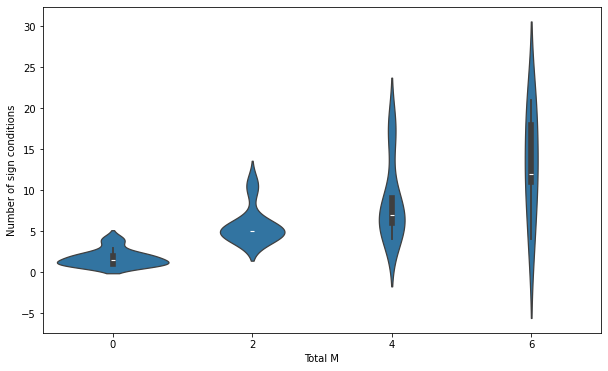

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

Text(0, 0.5, 'Number of sign conditions')

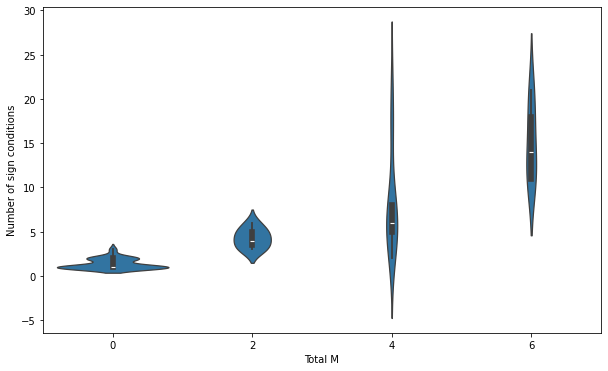

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

Text(0, 0.5, 'Number of sign conditions')

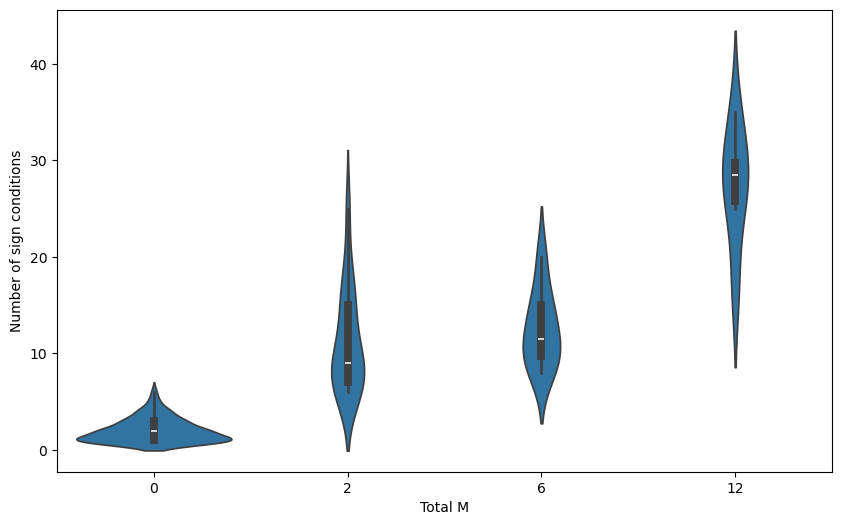

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

#plt.grid(True, alpha=0.3)

Text(0, 0.5, 'Number of sign conditions')

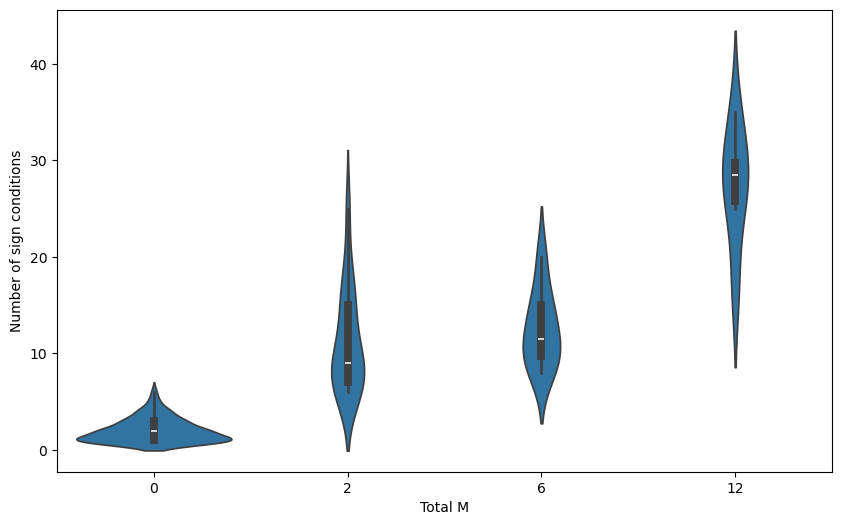

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

#plt.grid(True, alpha=0.3)

In [ ]:
import CRNs.sgolay2 as sgolay2
l0_x = [l0[0] for l0 in l0_list]
l0_y = [l0[1] for l0 in l0_list]
z_vals = [dC_dl_list[i][3,0] for i in range(len(dC_dl_list))]

x, y = np.meshgrid(
    np.logspace(np.log10(min(l0_x)), np.log10(max(l0_x)), 20),
    np.logspace(np.log10(min(l0_y)), np.log10(max(l0_y)), 20)
)



# Interpolate C_vals onto the grid
points = np.column_stack((l0_x, l0_y))
zn = griddata(points, z_vals, (x, y), method='linear')


zs = sgolay2.SGolayFilter2(3, 2)(zn)


fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(x, y, zn, linewidths=0.5, color='r', alpha=0.5)
ax.scatter(x, y, zn, s=5, c='r', alpha=0.5)

ax.plot_surface(x, y, zs, linewidth=0)


plt.show()

In [ ]:
import CRNs.sgolay2 as sgolay2
l0_x = [np.log10(l0[0]) for l0 in l0_list]
l0_y = [np.log10(l0[1]) for l0 in l0_list]
#C_vals = [np.log10(C_full[0]) for C_full in C_full_list]
sym_log = lambda x: np.sign(x)*np.log10(np.abs(x) + 1e-16)
#sym_log_inv = lambda y: np.sign(y) * (10**np.abs(y) - 1e-16)
sym_log_inv = lambda y: np.sign(y) * (10**y - 1e-16)

#z_vals = [dC_dl_list[i][3,0] for i in range(len(dC_dl_list))]
z_vals = [np.log10(C_full_list[i][3]) for i in range(len(C_full_list))]

x, y = np.meshgrid(
    np.linspace(min(l0_x), max(l0_x), 50),
    np.linspace(min(l0_y), max(l0_y), 50)
)


# Interpolate C_vals onto the grid
points = np.column_stack((l0_x, l0_y))
zn = griddata(points, z_vals, (x, y), method='linear') # does a linear interpolation


zs = sgolay2.SGolayFilter2(9, 2)(zn)

# zn_inv = sym_log_inv(zn)
# zs_inv = sym_log_inv(zs)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(x, y, zn, linewidths=0.5, color='r', alpha=0.5)
ax.scatter(x, y, zn, s=5, c='r', alpha=0.5)

ax.plot_surface(x, y, zs, linewidth=0)


plt.show()

In [ ]:
# Create two subplots - one for surface plot and one for contour plot
fig = plt.figure(figsize=(10, 6))

# Surface plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(grid_x, grid_y, C_interpolated, cmap='viridis')
fig.colorbar(surf, label='C_vals')
ax1.set_xlabel('log(l0[0])')
ax1.set_ylabel('log(l0[1])')
ax1.set_zlabel('C_vals')
ax1.set_title('3D Surface Plot')

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contour(grid_x, grid_y, C_interpolated, levels=15, cmap='viridis')
fig.colorbar(contour, label='C_vals')
ax2.set_xlabel('log(l0[0])')
ax2.set_ylabel('log(l0[1])')
ax2.set_title('Contour Plot')

plt.tight_layout()
plt.show()

In [ ]:
network_index = 0

ind_init = 9
l0_init = data_logger.get_network_by_index(network_index)['l0_list'][ind_init]
print(l0_init)
C_full_init = data_logger.get_network_by_index(network_index)['C_full_list'][ind_init]
_, C_reduced_init = sim.get_const_and_reduced_init(C_full_init)



t_span = (0, 10000)
num_points = 10000
int_method = 'Radau'
r_tol = 1e-4    
a_tol = 1e-4



l0 = l0_init + [0.1, 0.1]


time_start = time.time()
for _ in range(100):
    sampler._get_sign_sample_contour(l0_init, C_reduced_init, l0, sim, L, t_span, num_points, 'LSODA', r_tol, a_tol, precomputed_derivatives)
print(sampler._get_sign_sample_contour(l0_init, C_reduced_init, l0, sim, L, t_span, num_points, 'LSODA', r_tol, a_tol, precomputed_derivatives))
time_end = time.time()
print(f"Time taken: {time_end - time_start} seconds")

time_start = time.time()
for _ in range(100):
    sampler._get_sign_sample(l0, sim, L, t_span, num_points, int_method, r_tol, a_tol, precomputed_derivatives)
print(sampler._get_sign_sample(l0, sim, L, t_span, num_points, int_method, r_tol, a_tol, precomputed_derivatives))
time_end = time.time()
print(f"Time taken: {time_end - time_start} seconds")
